In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.datasets import mroz

from pymargins import GComputation, pairwise  # 0.4.0: Margins -> GComputation

cols = ["inlf", "nwifeinc", "educ", "exper", "age", "kidslt6", "kidsge6"]
df = mroz.load()[cols].dropna().copy()
df["expersq"] = df["exper"] ** 2
print(df.describe().round(2))

         inlf  nwifeinc    educ   exper     age  kidslt6  kidsge6  expersq
count  753.00    753.00  753.00  753.00  753.00   753.00   753.00   753.00
mean     0.57     20.13   12.29   10.63   42.54     0.24     1.35   178.04
std      0.50     11.63    2.28    8.07    8.07     0.52     1.32   249.63
min      0.00      0.03    5.00    0.00   30.00     0.00     0.00     0.00
25%      0.00     13.03   12.00    4.00   36.00     0.00     0.00    16.00
50%      1.00     17.70   12.00    9.00   43.00     0.00     1.00    81.00
75%      1.00     24.47   13.00   15.00   49.00     0.00     2.00   225.00
max      1.00     96.00   17.00   45.00   60.00     3.00     8.00  2025.00


In [2]:
fit = smf.glm(
    "inlf ~ nwifeinc + educ + exper + expersq + age + kidslt6 + kidsge6",
    data=df,
    family=sm.families.Binomial(),
).fit()
print(fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4255      0.860      0.495      0.621      -1.261       2.112
nwifeinc      -0.0213      0.008     -2.535      0.011      -0.038      -0.005
educ           0.2212      0.043      5.091      0.000       0.136       0.306
exper          0.2059      0.032      6.422      0.000       0.143       0.269
expersq       -0.0032      0.001     -3.104      0.002      -0.005      -0.001
age           -0.0880      0.015     -6.040      0.000      -0.117      -0.059
kidslt6       -1.4434      0.204     -7.090      0.000      -1.842      -1.044
kidsge6        0.0601      0.075      0.804      0.422      -0.086       0.207


In [3]:
m_ame = GComputation(fit, vcov="HC3", at="overall", scale="identity")
m_mem = GComputation(fit, vcov="HC3", at="typical", scale="identity")

print("AME (averaged over sample):")
print(m_ame.dydx("educ").summary())
print("\nMEM (at the typical profile):")
print(m_mem.dydx("educ").summary())

AME (averaged over sample):


            Graph Result (delta, level=0.95)            
      estimate  std err       z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------
educ    0.0410   0.0074  5.5788  0.000    0.0266, 0.0555

n = 753
Delta-vs-sim disagreement: 3.447%
plan a573d25@1 | κ = 0.051

MEM (at the typical profile):


            Graph Result (delta, level=0.95)            
      estimate  std err       z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------
educ    0.0571   0.0109  5.2543  0.000    0.0358, 0.0784

n = 753
Delta-vs-sim disagreement: 6.867%
plan daedcb5@1 | κ = 0.046


In [4]:
scen, w = pairwise("kidslt6", [1, 0])
delta = m_ame.contrasts(scenarios=scen, contrasts=w)
print(delta.summary())

               Graph Result (delta, level=0.95)               
           estimate  std err        z  P>|z|  [95% Conf. Int.]
--------------------------------------------------------------
kidslt6=1   -0.2697   0.0351  -7.6782  0.000  -0.3386, -0.2009

n = 753
Delta-vs-sim disagreement: 2.611%
plan a573d25@1 | κ = 0.056


In [5]:
print(m_ame.dydx("kidslt6").summary())

               Graph Result (delta, level=0.95)              
         estimate  std err         z  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------
kidslt6   -0.2573   0.0216  -11.9238  0.000  -0.2996, -0.2150

n = 753
Delta-vs-sim disagreement: 7.147%
plan a573d25@1 | κ = 0.260


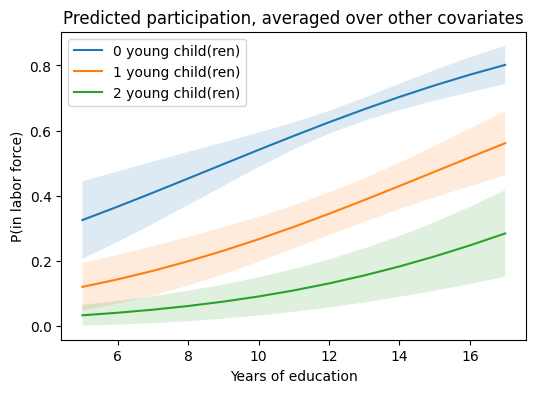

In [6]:
import matplotlib.pyplot as plt

educ_grid = list(range(5, 18))
res = m_ame.predict(atexog={"educ": educ_grid, "kidslt6": [0, 1, 2]})
df_plot = res.to_frame()

fig, ax = plt.subplots(figsize=(6, 4))
for k, sub in df_plot.groupby("kidslt6"):
    ax.plot(sub["educ"], sub["estimate"], label=f"{k} young child(ren)")
    ax.fill_between(
        sub["educ"], sub["ci_lower"], sub["ci_upper"], alpha=0.15
    )
ax.set(xlabel="Years of education",
       ylabel="P(in labor force)",
       title="Predicted participation, averaged over other covariates")
ax.legend()

In [7]:
m_boot = GComputation(fit, vcov="HC3", at="overall",
    method="bootstrap", B=400, seed=0, scale="identity")
print(m_boot.contrasts(scenarios=scen, contrasts=w).summary())

              Graph Result (bootstrap, level=0.95)              
           estimate  std err  statistic  P>|z|  [95% Conf. Int.]
----------------------------------------------------------------
kidslt6=1   -0.2697   0.0354    -0.2697  0.000  -0.3426, -0.2041

n = 753
plan 59c4011@1 | κ = 0.056
